# **Customer Segmentation Using K-Means Clustering**

This analysis focuses on segmenting telecommunications customers into meaningful groups using K-Means clustering. The objective is to identify distinct customer segments based on demographic and service-related attributes to support churn analysis and retention strategy development.

In [23]:
# Import required libraries for data handling, clustering, and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


## **Dataset Loading and Validation**

The preprocessed customer dataset provided by the Data Engineering team was loaded into the analysis environment. The dataset was previously cleaned, encoded, and scaled to ensure suitability for clustering analysis.

Dataset dimensions were verified to confirm successful loading and data integrity before proceeding with segmentation.

In [24]:
# Load the preprocessed customer dataset provided by the Data Engineer
data = pd.read_csv("churn_clustering_ready.csv")


# Display first few rows to verify successful loading
data.head()


,Gender,Senior Citizen,Dependants,Tenure in Months,Phone Service,Multiple Lines,Monthly Charges in $,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,Internet Service_DSL,Internet Service_Fiber optic
0,0,0,0,-1.312875,0,0,-1.376228,1,1,0,0,1,0
1,1,0,0,0.331038,1,0,-1.376228,0,0,1,0,1,0
2,0,0,1,0.783114,1,0,-1.578399,0,1,0,0,1,0
3,0,0,0,-1.312875,1,0,0.342225,1,0,1,0,1,0
4,1,0,0,1.399582,1,0,-0.500154,0,1,0,0,0,1


In [25]:
# Check the number of rows and columns in the dataset
# This helps verify that the dataset was loaded correctly
data.shape



(6741, 13)

## **Feature Preparation for Clustering Analysis**

Since K-Means is an unsupervised learning algorithm, the target variable Churn was excluded from the clustering process. This ensures that customer segments are formed purely based on behavioural and demographic similarities rather than predefined outcomes.

The remaining features were used to identify natural groupings within the customer base.

In [26]:
# Remove 'Churn' column before clustering
# K-Means is an unsupervised algorithm and should not use target labels
X = data.drop('Churn', axis=1)

X.head()


,Gender,Senior Citizen,Dependants,Tenure in Months,Phone Service,Multiple Lines,Monthly Charges in $,Contract_Month-to-month,Contract_One year,Contract_Two year,Internet Service_DSL,Internet Service_Fiber optic
0,0,0,0,-1.312875,0,0,-1.376228,1,0,0,1,0
1,1,0,0,0.331038,1,0,-1.376228,0,1,0,1,0
2,0,0,1,0.783114,1,0,-1.578399,1,0,0,1,0
3,0,0,0,-1.312875,1,0,0.342225,0,1,0,1,0
4,1,0,0,1.399582,1,0,-0.500154,1,0,0,0,1


## **Determining the Optimal Number of Customer Segments**
The Elbow Method was applied to determine the optimal number of clusters. This technique evaluates the within-cluster variance (inertia) for different values of K.

A noticeable bend in the inertia curve was observed at K = 4, indicating diminishing improvements beyond this point. Therefore, four clusters were selected as the optimal number of customer segments.

In [27]:
# Apply Elbow Method to determine optimal number of clusters
# Inertia measures within-cluster variance

inertia = []

K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

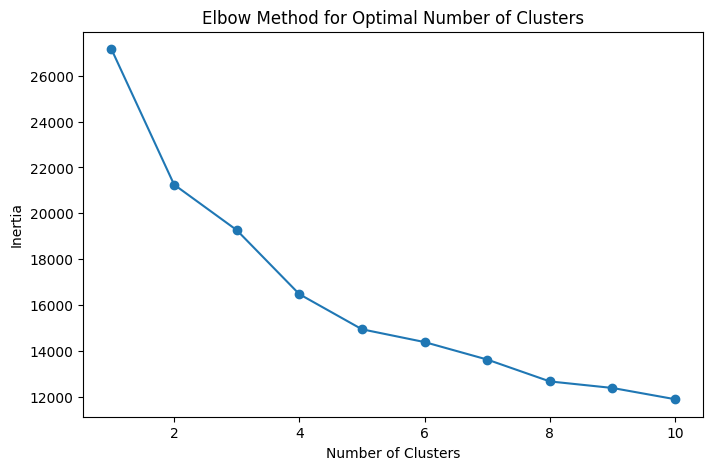

In [28]:
# ELBOW CURVE
# # Plot inertia values to visually identify optimal cluster number
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()



## **Customer Segmentation Using K-Means**

A K-Means clustering model was trained using the optimal number of clusters identified through the Elbow Method. Each customer was assigned to a cluster representing similar characteristics and service usage patterns.

The resulting cluster labels were appended to the dataset for further analysis and interpretation.

In [29]:

from sklearn.cluster import KMeans
# Train K-Means model using optimal number of clusters (K = 4)
kmeans = KMeans(n_clusters=4, random_state=42)

# Assign cluster labels to each customer
data['Cluster'] = kmeans.fit_predict(X)


## **Verification of Cluster Assignment**

The clustering results were validated by checking the unique cluster labels generated by the K-Means algorithm. The output confirms that customers were successfully segmented into four distinct clusters.

A preview of the dataset was displayed to ensure that cluster assignments were correctly added.

In [30]:
# Verification of Cluster Assignment
sorted(data['Cluster'].unique())
data.head()



,Gender,Senior Citizen,Dependants,Tenure in Months,Phone Service,Multiple Lines,Monthly Charges in $,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,Internet Service_DSL,Internet Service_Fiber optic,Cluster
0,0,0,0,-1.312875,0,0,-1.376228,1,1,0,0,1,0,0
1,1,0,0,0.331038,1,0,-1.376228,0,0,1,0,1,0,0
2,0,0,1,0.783114,1,0,-1.578399,0,1,0,0,1,0,0
3,0,0,0,-1.312875,1,0,0.342225,1,0,1,0,1,0,2
4,1,0,0,1.399582,1,0,-0.500154,0,1,0,0,0,1,1


## **Visualisation of Customer Segments**

Principal Component Analysis (PCA) was applied to reduce the dataset dimensions to two components for visualization purposes. This enables graphical representation of customer segments while preserving underlying data variance.

The scatter plot illustrates the separation between customer groups formed through clustering.

In [31]:
# Reduce dataset dimensions to 2 components for visualization purposes
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)


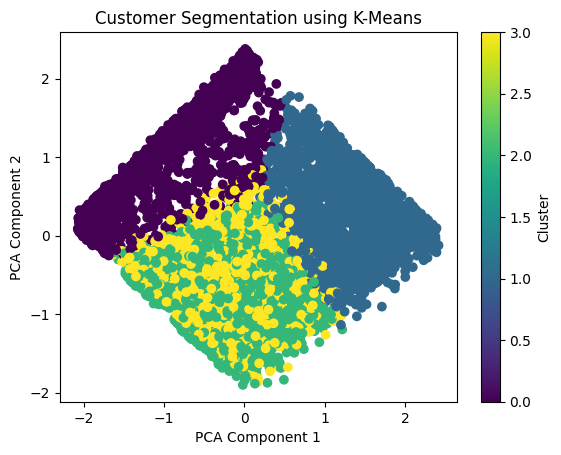

In [32]:
# Visualize customer segments formed by K-Means clustering
plt.scatter(
    pca_components[:,0],
    pca_components[:,1],
    c=data['Cluster'],
    cmap='viridis'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


## **Linking Customer Segmentation to Churn Behaviour**

Although clustering was performed without using churn labels, churn rates were analysed across clusters after segmentation. This allows identification of customer groups with higher churn risk and supports targeted retention initiatives.

In [35]:
# Cluster Interpretation
data.groupby('Cluster')['Churn'].mean()


,Churn
Cluster,
0,0.117328
1,0.144590
2,0.455873
3,0.422205


## **Cluster Profiling and Analysis**

To interpret customer segments, average feature values within each cluster were analysed. This profiling helps identify behavioural patterns, service preferences, and potential churn tendencies associated with each customer group.

The insights derived from this analysis support data-driven decision-making for customer retention strategies.

In [34]:
# Analyse average feature values within each cluster
cluster_summary = data.groupby('Cluster').mean()
cluster_summary


,Gender,Senior Citizen,Dependants,Tenure in Months,Phone Service,Multiple Lines,Monthly Charges in $,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,Internet Service_DSL,Internet Service_Fiber optic
Cluster,,,,,,,,,,,,,
0,0.505160,0.063009,0.412819,-0.064804,0.756111,0.406844,-1.353331,0.117328,0.518740,0.242803,0.238457,0.560022,0.439978
1,0.495450,0.208291,0.347321,1.119938,0.941860,0.426188,0.806666,0.144590,0.552073,0.205258,0.242669,0.557128,0.442872
2,0.488740,0.217285,0.200852,-0.735354,0.964699,0.269629,0.315277,0.455873,0.431528,0.233110,0.335362,1.000000,0.000000
3,0.531665,0.191556,0.214230,-0.694094,0.960125,0.634089,0.295463,0.422205,0.701329,0.158718,0.139953,0.000000,1.000000
